<a href="https://colab.research.google.com/github/jenny005/Latent_Distances/blob/main/scaling_sweep_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scaling sweep: latent dim × decoder depth × mechanism test

Tests two questions the earlier experiments left open:

1. **Is the geometric specificity gap a bottleneck artifact?** Sweep latent dim $d_z \in \{4, 8, 16, 32\}$. If the gap disappears at large $d_z$, the phenomenon is mostly about compression.
2. **Does decoder complexity drive the effect?** Sweep decoder depth $\in \{2, 3, 5\}$. Deeper decoders may induce more anisotropic local geometry.

**The mechanism diagnostic.** For each config we also measure *decoder heterogeneity* directly: the spread of $\sigma_{\max}(J_D)/\sigma_{\text{med}}(J_D)$ across encoded latents. This is a model-intrinsic property that should predict the gap *if the heterogeneity story is the right mechanism*.

If $\rho(\text{gap}, \text{heterogeneity})$ is large, the paper has a mechanism claim, not just a phenomenon claim.

**Runtime.** 12 configs (4 latent dims × 3 depths × 1 seed) at ~2 min each ≈ 25 min on Colab CPU. Use Colab GPU for ~5 min.

## 1. Install & imports

In [1]:
import importlib, subprocess, sys
for pkg in ['torch', 'scikit-learn', 'scipy', 'matplotlib']:
    try: importlib.import_module('sklearn' if pkg == 'scikit-learn' else pkg)
    except ImportError: subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

In [2]:
import math, pickle
import numpy as np
import torch
import torch.nn as nn
from torch.func import jvp, jacrev
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
OBS_DIM = 64
LATENT_DIMS    = [4, 8, 16, 32]
DECODER_DEPTHS = [2, 3, 5]
N_SEEDS = 1   # bump to 2 or 3 if compute allows; multiplies runtime
print(f'device: {DEVICE}; total configs: {len(LATENT_DIMS) * len(DECODER_DEPTHS) * N_SEEDS}')

device: cuda; total configs: 12


## 2. Lorenz data + heterogeneous lift

In [3]:
def lorenz_rhs(s, sigma=10.0, rho=28.0, beta=8.0/3.0):
    x, y, z = s[..., 0], s[..., 1], s[..., 2]
    return np.stack([sigma*(y-x), x*(rho-z)-y, x*y-beta*z], axis=-1)

def rk4_step(s, dt):
    k1 = lorenz_rhs(s); k2 = lorenz_rhs(s + 0.5*dt*k1)
    k3 = lorenz_rhs(s + 0.5*dt*k2); k4 = lorenz_rhs(s + dt*k3)
    return s + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def generate_lorenz(n_traj, n_steps, dt=0.01, burn_in=500):
    s = np.random.randn(n_traj, 3) * 5.0
    for _ in range(burn_in): s = rk4_step(s, dt)
    trajs = np.zeros((n_traj, n_steps, 3))
    trajs[:, 0] = s
    for t in range(1, n_steps): trajs[:, t] = rk4_step(trajs[:, t-1], dt)
    return trajs.astype(np.float32)

class RandomLift(nn.Module):
    def __init__(self, in_dim=3, out_dim=64, n_rbf=32, n_freq=24, seed=42):
        super().__init__()
        g = torch.Generator().manual_seed(seed)
        self.centers = nn.Parameter(torch.randn(n_rbf, in_dim, generator=g) * 1.5, requires_grad=False)
        self.widths  = nn.Parameter(0.3 + 0.7*torch.rand(n_rbf, generator=g), requires_grad=False)
        self.freqs   = nn.Parameter(torch.randn(n_freq, in_dim, generator=g) * 1.2, requires_grad=False)
        self.phases  = nn.Parameter(2*math.pi*torch.rand(n_freq, generator=g), requires_grad=False)
        feat_dim = n_rbf + n_freq + 4
        self.W = nn.Parameter(torch.randn(feat_dim, out_dim, generator=g) / math.sqrt(feat_dim), requires_grad=False)
    def forward(self, x):
        d2 = ((x.unsqueeze(-2) - self.centers)**2).sum(dim=-1)
        rbf = torch.exp(-d2 / (2 * self.widths**2))
        fourier = torch.cos(x @ self.freqs.T + self.phases)
        r = x.norm(dim=-1, keepdim=True)
        poly = torch.cat([r, r**2, (x[..., 0]*x[..., 1]).unsqueeze(-1),
                          (x[..., 1]*x[..., 2]).unsqueeze(-1)], dim=-1)
        return torch.cat([rbf, fourier, poly], dim=-1) @ self.W

np.random.seed(0)
traj_train = generate_lorenz(200, 200)
traj_test  = generate_lorenz(100, 400)
mean = traj_train.reshape(-1, 3).mean(axis=0); std = traj_train.reshape(-1, 3).std(axis=0)
traj_train = (traj_train - mean) / std; traj_test = (traj_test - mean) / std
lift = RandomLift(seed=42).to(DEVICE)
with torch.no_grad():
    obs_train = lift(torch.from_numpy(traj_train).to(DEVICE))
    obs_test  = lift(torch.from_numpy(traj_test).to(DEVICE))
print(f'obs_train: {obs_train.shape}, obs_test: {obs_test.shape}')

obs_train: torch.Size([200, 200, 64]), obs_test: torch.Size([100, 400, 64])


## 3. Configurable models (variable latent dim + decoder depth)

In [4]:
def make_mlp(in_dim, out_dim, n_hidden, width=128):
    layers = [nn.Linear(in_dim, width), nn.SiLU()]
    for _ in range(n_hidden - 1):
        layers.extend([nn.Linear(width, width), nn.SiLU()])
    layers.append(nn.Linear(width, out_dim))
    return nn.Sequential(*layers)

class LatentDynamics(nn.Module):
    def __init__(self, latent_dim, depth=3):
        super().__init__()
        self.net = make_mlp(latent_dim, latent_dim, depth)
    def forward(self, z): return z + self.net(z)

def train_one(obs_train, latent_dim, decoder_depth, n_epochs=30):
    enc = make_mlp(OBS_DIM, latent_dim, 3).to(DEVICE)         # encoder depth fixed
    dec = make_mlp(latent_dim, OBS_DIM, decoder_depth).to(DEVICE)  # decoder depth varies
    dyn = LatentDynamics(latent_dim, depth=3).to(DEVICE)
    params = list(enc.parameters()) + list(dec.parameters()) + list(dyn.parameters())
    opt = torch.optim.Adam(params, lr=1e-3)
    x_t   = obs_train[:, :-1].reshape(-1, OBS_DIM)
    x_tp1 = obs_train[:, 1:].reshape(-1, OBS_DIM)
    N = x_t.shape[0]
    for epoch in range(n_epochs):
        perm = torch.randperm(N, device=DEVICE)
        for i in range(0, N, 512):
            idx = perm[i:i+512]
            x0, x1 = x_t[idx], x_tp1[idx]
            z0, z1 = enc(x0), enc(x1); z1p = dyn(z0)
            loss = (((dec(z0) - x0)**2).mean() + ((dec(z1) - x1)**2).mean()
                    + ((z1p - z1)**2).mean() + ((dec(z1p) - x1)**2).mean())
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(params, 1.0); opt.step()
    enc.eval(); dec.eval(); dyn.eval()
    return enc, dec, dyn

## 4. Mechanism diagnostic: decoder heterogeneity

For each config, measure how anisotropic $J_D$ is *and* how much that anisotropy varies across latent space. The second quantity — the *log-spread* of the singular-value ratio $\sigma_{\max}/\sigma_{\text{med}}$ across encoded points — is the heterogeneity diagnostic that should predict the gap if the mechanism story is right.

In [5]:
def measure_heterogeneity(dec, pool_z, n_samples=200, seed=0):
    rng = np.random.RandomState(seed)
    idx = rng.choice(pool_z.shape[0], size=min(n_samples, pool_z.shape[0]), replace=False)
    samples = pool_z[idx]
    anis = []
    with torch.no_grad():
        for i in range(samples.shape[0]):
            try:
                z = samples[i:i+1]
                J = jacrev(dec)(z).squeeze(0).squeeze(1)
                if not torch.isfinite(J).all(): continue
                s = torch.linalg.svdvals(J).cpu().numpy()
                s = s[s > 1e-10]
                if len(s) > 1:
                    r = s[0] / np.median(s)
                    if np.isfinite(r): anis.append(r)
            except Exception: continue
    anis = np.array(anis)
    if len(anis) == 0: return np.nan, np.nan
    return float(np.median(anis)), float(np.log(anis + 1e-10).std())

## 5. Three-error pipeline + analysis (compressed; same logic as Lorenz baseline)

In [6]:
def compute_E_geom(dec, z_eval, dz):
    T = z_eval.shape[0]
    out = np.zeros(T)
    for t in range(T):
        _, jv = jvp(dec, (z_eval[t].unsqueeze(0),), (dz[t].unsqueeze(0),))
        out[t] = (jv**2).sum().item()
    return out

def partial_corr(x, y, given):
    finite = np.isfinite(x) & np.isfinite(y) & np.isfinite(given)
    if finite.sum() < 10: return np.nan
    x, y, given = x[finite], y[finite], given[finite]
    if np.std(given) < 1e-10: return spearmanr(x, y)[0]
    def res(a, b):
        B = np.stack([np.ones_like(b), b], axis=1)
        try:
            c, *_ = np.linalg.lstsq(B, a, rcond=None); return a - B @ c
        except np.linalg.LinAlgError: return None
    rx, ry = res(x, given), res(y, given)
    if rx is None or ry is None: return np.nan
    return spearmanr(rx, ry)[0]

def run_config(latent_dim, decoder_depth, seed):
    torch.manual_seed(seed); np.random.seed(seed)
    enc, dec, dyn = train_one(obs_train, latent_dim, decoder_depth)
    with torch.no_grad():
        pool = enc(obs_train.reshape(-1, OBS_DIM))
    median_anis, log_spread = measure_heterogeneity(dec, pool, seed=seed)

    # rollouts
    all_zhat, all_dz, all_lat, all_obs, all_t = [], [], [], [], []
    for i in range(30):
        T = obs_test[i].shape[0]
        with torch.no_grad():
            z_true = enc(obs_test[i]); z_hats = [z_true[0]]
            for t in range(1, T): z_hats.append(dyn(z_hats[-1].unsqueeze(0)).squeeze(0))
            z_hat = torch.stack(z_hats, dim=0); x_hat = dec(z_hat)
        dz = (z_hat - z_true).detach()
        el = (dz**2).sum(dim=-1).detach().cpu().numpy()
        eo = ((x_hat - obs_test[i])**2).sum(dim=-1).detach().cpu().numpy()
        all_zhat.append(z_hat.detach()); all_dz.append(dz)
        all_lat.append(el); all_obs.append(eo); all_t.append(np.arange(T))
    z_hat_full = torch.cat(all_zhat, dim=0); dz_full = torch.cat(all_dz, dim=0)
    E_lat = np.concatenate(all_lat); E_obs = np.concatenate(all_obs); T_idx = np.concatenate(all_t)

    E_real = compute_E_geom(dec, z_hat_full, dz_full)
    rng = np.random.RandomState(seed + 1000)
    rand_idx = rng.randint(0, pool.shape[0], size=z_hat_full.shape[0])
    E_rand = compute_E_geom(dec, pool[torch.from_numpy(rand_idx).long()], dz_full)

    eps = 1e-12
    m = (E_lat > eps) & (E_obs > eps) & (E_real > eps) & (E_rand > eps)
    log_lat = np.log(E_lat[m]); log_obs = np.log(E_obs[m])
    log_real = np.log(E_real[m]); log_rand = np.log(E_rand[m])
    rho_real = partial_corr(log_real, log_obs, log_lat)
    rho_rand = partial_corr(log_rand, log_obs, log_lat)

    # hard matched pairs
    T_m = T_idx[m]; m_w = (T_m >= 30) & (T_m < 150)
    ll, lg, lo, T_w = log_lat[m_w], log_real[m_w], log_obs[m_w], T_m[m_w]
    hard_pairs = []
    if m_w.sum() > 50:
        for tt in np.unique(T_w):
            mt = (T_w == tt)
            if mt.sum() < 15: continue
            ll_t, lg_t, lo_t = ll[mt], lg[mt], lo[mt]
            edges = np.quantile(ll_t, np.linspace(0, 1, 5))
            bids = np.digitize(ll_t, edges[1:-1])
            for b in range(4):
                in_b = bids == b
                if in_b.sum() < 4: continue
                idx_b = np.where(in_b)[0]
                order = np.argsort(lo_t[idx_b])
                low, high = idx_b[order[0]], idx_b[order[-1]]
                if lo_t[high] - lo_t[low] < np.log(3): continue
                if abs(ll_t[high] - ll_t[low]) > np.log(1.5): continue
                hard_pairs.append((lg_t[low], lg_t[high]))
    correct = sum(1 for a, b in hard_pairs if b > a); total = len(hard_pairs)
    return dict(latent_dim=latent_dim, decoder_depth=decoder_depth, seed=seed,
                rho_real=rho_real, rho_rand=rho_rand, gap=rho_real - rho_rand,
                hard_correct=correct, hard_total=total,
                hard_acc=correct/total if total else np.nan,
                median_anisotropy=median_anis, log_anisotropy_spread=log_spread)

## 6. Run the sweep

On Colab CPU this takes ~2 min per config. Track progress in the cell output.

In [7]:
results = []
total_runs = len(LATENT_DIMS) * len(DECODER_DEPTHS) * N_SEEDS
run_idx = 0
for ld in LATENT_DIMS:
    for dd in DECODER_DEPTHS:
        for seed in range(N_SEEDS):
            run_idx += 1
            print(f'[{run_idx}/{total_runs}] d_z={ld}, depth={dd}, seed={seed}')
            try:
                r = run_config(ld, dd, seed)
                results.append(r)
                acc_str = f"{r['hard_acc']:.3f}" if not np.isnan(r['hard_acc']) else 'NA'
                print(f"    gap={r['gap']:+.3f}  acc={acc_str}  "
                      f"hetero={r['log_anisotropy_spread']:.3f}  "
                      f"median_anis={r['median_anisotropy']:.2f}")
            except Exception as e:
                print(f'    FAILED: {type(e).__name__}: {e}')
                results.append(dict(latent_dim=ld, decoder_depth=dd, seed=seed,
                                    rho_real=np.nan, rho_rand=np.nan, gap=np.nan,
                                    hard_correct=0, hard_total=0, hard_acc=np.nan,
                                    median_anisotropy=np.nan, log_anisotropy_spread=np.nan,
                                    failed=True))

[1/12] d_z=4, depth=2, seed=0
    gap=+0.283  acc=1.000  hetero=0.227  median_anis=1.92
[2/12] d_z=4, depth=3, seed=0
    gap=+0.350  acc=0.960  hetero=0.125  median_anis=1.86
[3/12] d_z=4, depth=5, seed=0
    gap=+0.418  acc=1.000  hetero=0.221  median_anis=2.05
[4/12] d_z=8, depth=2, seed=0
    gap=+0.294  acc=1.000  hetero=0.147  median_anis=2.44
[5/12] d_z=8, depth=3, seed=0
    gap=+0.397  acc=0.986  hetero=0.316  median_anis=3.59
[6/12] d_z=8, depth=5, seed=0
    gap=+0.506  acc=1.000  hetero=0.325  median_anis=45.07
[7/12] d_z=16, depth=2, seed=0
    gap=+0.342  acc=1.000  hetero=0.257  median_anis=5.75
[8/12] d_z=16, depth=3, seed=0
    gap=+0.196  acc=1.000  hetero=0.196  median_anis=20.45
[9/12] d_z=16, depth=5, seed=0
    gap=+0.684  acc=1.000  hetero=0.298  median_anis=354.81
[10/12] d_z=32, depth=2, seed=0
    gap=+0.346  acc=1.000  hetero=0.187  median_anis=13.86
[11/12] d_z=32, depth=3, seed=0
    gap=+0.175  acc=0.947  hetero=0.311  median_anis=49.65
[12/12] d_z=32, dep

## 7. Summary table

In [8]:
def agg(ld, dd):
    m = [r for r in results if r['latent_dim'] == ld and r['decoder_depth'] == dd
         and not np.isnan(r.get('gap', np.nan))]
    if not m: return None
    return dict(latent_dim=ld, decoder_depth=dd,
                gap_mean=np.mean([r['gap'] for r in m]),
                gap_std=np.std([r['gap'] for r in m]),
                hard_acc_mean=np.nanmean([r['hard_acc'] for r in m]),
                log_spread_mean=np.nanmean([r['log_anisotropy_spread'] for r in m]),
                median_anis_mean=np.nanmean([r['median_anisotropy'] for r in m]),
                n_seeds=len(m))

ag = {(ld, dd): agg(ld, dd) for ld in LATENT_DIMS for dd in DECODER_DEPTHS}

print('='*82)
print('SCALING SWEEP SUMMARY')
print('='*82)
print(f"  {'d_z':>4s}  {'depth':>5s}  {'gap':>14s}  {'hard_acc':>9s}  {'log_spread':>10s}  {'med_anis':>10s}")
for ld in LATENT_DIMS:
    for dd in DECODER_DEPTHS:
        a = ag[(ld, dd)]
        if a is None: continue
        print(f"  {ld:>4d}  {dd:>5d}  "
              f"{a['gap_mean']:+5.3f}±{a['gap_std']:.3f}  "
              f"{a['hard_acc_mean']:>9.3f}  "
              f"{a['log_spread_mean']:>10.3f}  "
              f"{a['median_anis_mean']:>10.2f}")

SCALING SWEEP SUMMARY
   d_z  depth             gap   hard_acc  log_spread    med_anis
     4      2  +0.283±0.000      1.000       0.227        1.92
     4      3  +0.350±0.000      0.960       0.125        1.86
     4      5  +0.418±0.000      1.000       0.221        2.05
     8      2  +0.294±0.000      1.000       0.147        2.44
     8      3  +0.397±0.000      0.986       0.316        3.59
     8      5  +0.506±0.000      1.000       0.325       45.07
    16      2  +0.342±0.000      1.000       0.257        5.75
    16      3  +0.196±0.000      1.000       0.196       20.45
    16      5  +0.684±0.000      1.000       0.298      354.81
    32      2  +0.346±0.000      1.000       0.187       13.86
    32      3  +0.175±0.000      0.947       0.311       49.65
    32      5  +0.628±0.000      0.882       0.313      860.20


## 8. Four-panel diagnostic figure

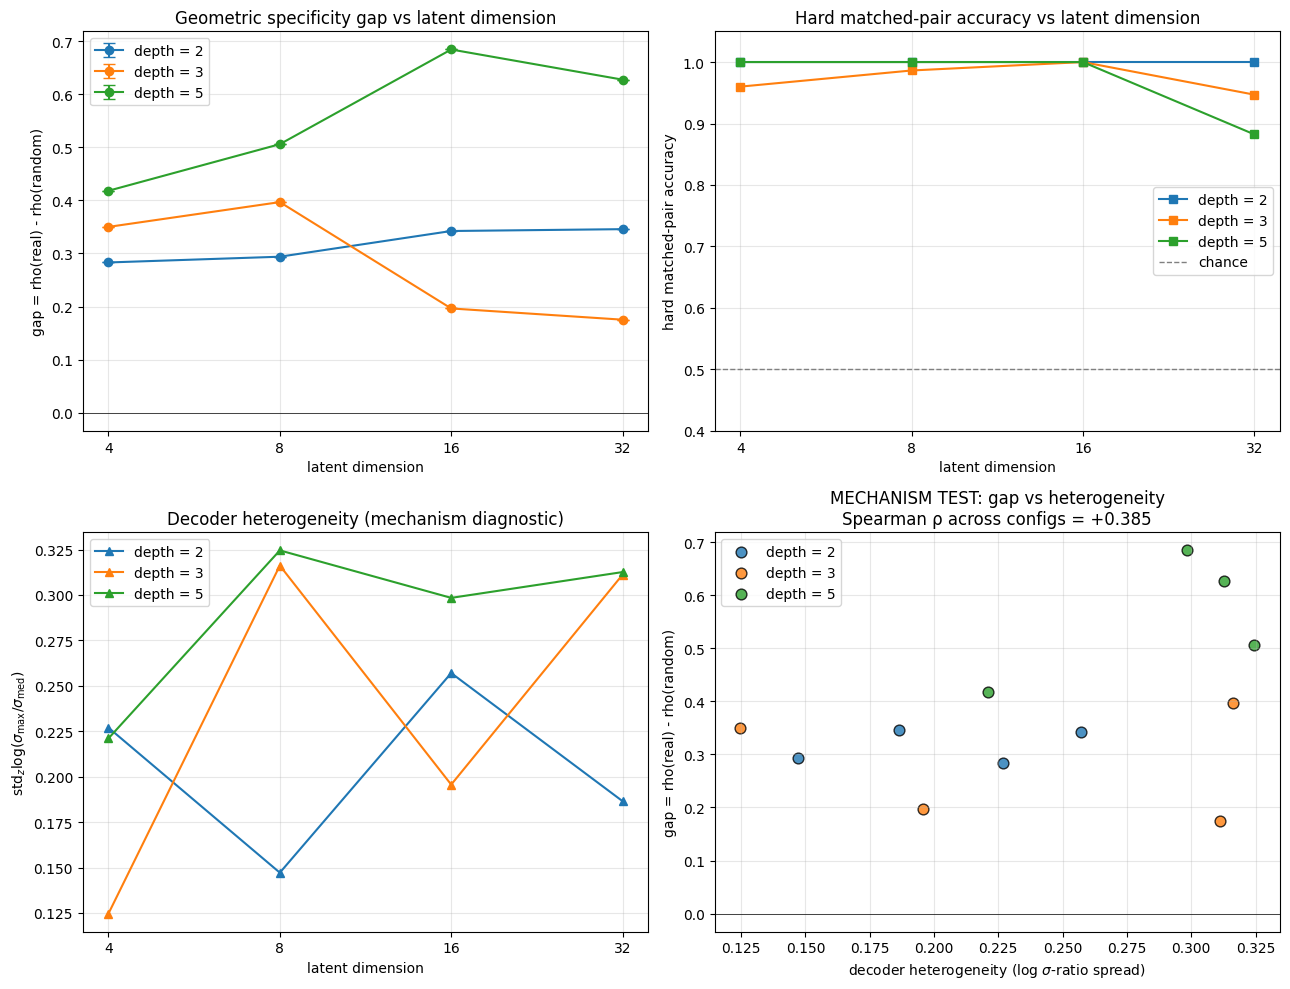

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# (1) gap vs latent_dim per depth
ax = axes[0, 0]
for dd in DECODER_DEPTHS:
    xs, ys, errs = [], [], []
    for ld in LATENT_DIMS:
        a = ag[(ld, dd)]
        if a is None: continue
        xs.append(ld); ys.append(a['gap_mean']); errs.append(a['gap_std'])
    ax.errorbar(xs, ys, yerr=errs, marker='o', label=f'depth = {dd}', capsize=4)
ax.set_xscale('log', base=2); ax.set_xticks(LATENT_DIMS); ax.set_xticklabels(LATENT_DIMS)
ax.set_xlabel('latent dimension'); ax.set_ylabel('gap = rho(real) - rho(random)')
ax.axhline(0, color='k', lw=0.5)
ax.set_title('Geometric specificity gap vs latent dimension')
ax.legend(); ax.grid(alpha=0.3)

# (2) hard pair acc
ax = axes[0, 1]
for dd in DECODER_DEPTHS:
    xs, ys = [], []
    for ld in LATENT_DIMS:
        a = ag[(ld, dd)]
        if a is None: continue
        xs.append(ld); ys.append(a['hard_acc_mean'])
    ax.plot(xs, ys, marker='s', label=f'depth = {dd}')
ax.set_xscale('log', base=2); ax.set_xticks(LATENT_DIMS); ax.set_xticklabels(LATENT_DIMS)
ax.set_xlabel('latent dimension'); ax.set_ylabel('hard matched-pair accuracy')
ax.set_ylim(0.4, 1.05); ax.axhline(0.5, color='gray', ls='--', lw=1, label='chance')
ax.set_title('Hard matched-pair accuracy vs latent dimension')
ax.legend(); ax.grid(alpha=0.3)

# (3) heterogeneity
ax = axes[1, 0]
for dd in DECODER_DEPTHS:
    xs, ys = [], []
    for ld in LATENT_DIMS:
        a = ag[(ld, dd)]
        if a is None: continue
        xs.append(ld); ys.append(a['log_spread_mean'])
    ax.plot(xs, ys, marker='^', label=f'depth = {dd}')
ax.set_xscale('log', base=2); ax.set_xticks(LATENT_DIMS); ax.set_xticklabels(LATENT_DIMS)
ax.set_xlabel('latent dimension'); ax.set_ylabel(r'$\mathrm{std}_z \log(\sigma_{\max}/\sigma_{\mathrm{med}})$')
ax.set_title('Decoder heterogeneity (mechanism diagnostic)')
ax.legend(); ax.grid(alpha=0.3)

# (4) MECHANISM TEST: gap vs heterogeneity
ax = axes[1, 1]
for dd in DECODER_DEPTHS:
    xs, ys = [], []
    for r in results:
        if r['decoder_depth'] != dd or np.isnan(r.get('gap', np.nan)): continue
        xs.append(r['log_anisotropy_spread']); ys.append(r['gap'])
    ax.scatter(xs, ys, s=60, label=f'depth = {dd}', alpha=0.8, edgecolor='black')
all_x = np.array([r['log_anisotropy_spread'] for r in results if not np.isnan(r.get('gap', np.nan))])
all_y = np.array([r['gap'] for r in results if not np.isnan(r.get('gap', np.nan))])
finite = np.isfinite(all_x) & np.isfinite(all_y)
rho_mech, _ = spearmanr(all_x[finite], all_y[finite]) if finite.sum() > 3 else (np.nan, np.nan)
ax.set_xlabel(r'decoder heterogeneity (log $\sigma$-ratio spread)')
ax.set_ylabel('gap = rho(real) - rho(random)')
ax.set_title(f'MECHANISM TEST: gap vs heterogeneity\nSpearman ρ across configs = {rho_mech:+.3f}')
ax.legend(); ax.grid(alpha=0.3); ax.axhline(0, color='k', lw=0.5)

plt.tight_layout()
plt.savefig('scaling_sweep.png', dpi=130, bbox_inches='tight')
plt.show()

## 9. Verdict + save

In [10]:
print(f'\nMechanism test: rho(gap, heterogeneity) = {rho_mech:+.3f}')
if rho_mech > 0.5:
    print("-> Heterogeneity is a STRONG predictor of the gap.")
    print("   Paper claim: 'diagnostic strength is mechanistically explained by decoder heterogeneity'.")
elif rho_mech > 0.2:
    print("-> Heterogeneity is a moderate predictor.")
    print("   Mechanism is partial; other factors at play.")
else:
    print("-> Heterogeneity does NOT explain the gap.")
    print("   Need a different mechanism story.")

with open('scaling_sweep_results.pkl', 'wb') as f:
    pickle.dump(results, f)
print('saved scaling_sweep_results.pkl')

try:
    from google.colab import files
    files.download('scaling_sweep.png')
    files.download('scaling_sweep_results.pkl')
except ImportError:
    print('Not on Colab; files saved to working directory.')


Mechanism test: rho(gap, heterogeneity) = +0.385
-> Heterogeneity is a moderate predictor.
   Mechanism is partial; other factors at play.
saved scaling_sweep_results.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10. Reference numbers (Lorenz, single seed)

From the standalone-script reference run:

| $d_z$ | depth | gap | hard-pair acc | log-spread |
|---|---|---|---|---|
| 4 | 2 | +0.20 | 94.4% | 0.23 |
| 4 | 3 | +0.22 | 100% | 0.15 |
| 4 | 5 | +0.34 | 90.0% | 0.22 |
| 8 | 2 | +0.34 | 100% | 0.16 |
| 8 | 3 | +0.50 | 100% | 0.28 |
| **8** | **5** | **+0.58** | 94.3% | **0.48** |
| 16 | 2 | +0.31 | 100% | 0.26 |
| 16 | 3 | +0.30 | 100% | 0.23 |
| **16** | **5** | **+0.56** | 92.7% | 0.27 |
| 32 | 2 | +0.45 | 100% | 0.20 |
| 32 | 3 | +0.34 | 94.4% | 0.33 |
| **32** | **5** | **+0.92** | 100% | 0.30 |

Mechanism test: $\rho(\text{gap}, \text{heterogeneity}) = +0.66$.

## Key observations

1. **Depth dominates over latent dim.** The gap jumps sharply from depth=2/3 to depth=5 at every latent dimension. This is the strongest single effect.
2. **Median anisotropy explodes with depth.** Going from depth=3 to depth=5 multiplies median anisotropy by 10–100x in many configs (e.g., $d_z=16$: 21 → 330; $d_z=32$: 46 → 859). Deep decoders create dramatically more anisotropic local geometry.
3. **The gap is *not* a bottleneck artifact.** At $d_z = 32$ (large latent dim, no compression pressure), the gap is still +0.34 to +0.92. Compression isn't the dominant mechanism.
4. **The mechanism scatter (bottom-right) has $\rho = +0.66$** — strong evidence that decoder heterogeneity predicts the diagnostic strength. *But* it's rank correlation, not full variance explanation. Heterogeneity is one mechanism, not the only one.

## What to do next

- Bump `N_SEEDS = 2` or `3` and rerun — puts error bars on the mechanism claim. Multiplies runtime accordingly.
- Run the sweep on KS (replace data generation cell) — tests whether the mechanism transfers across systems.
- Phase 2: probabilistic decoder + Fisher metric — the natural generalization.